# Fine-Tuning Summarization Models for Gen Z Style Transfer

This notebook implements the training and evaluation pipeline of two model architectures designed to transform Reddit-sourced TL;DR summaries into authentic Gen Z–style summaries. Following successful synthetic data generation via large language models, this notebook focuses on supervised fine-tuning (SFT) of pretrained sequence-to-sequence models (T5-small and BART-base) to learn the mapping between stylistically neutral and Gen Z style summaries.

## Imports
After importing the packages, we also initialize a BERT Scorer, which will be used later as a part of the evaluation.

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn.functional as F
import kagglehub
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import pandas as pd

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    GenerationConfig
)

from datasets import load_dataset, DatasetDict
from bert_score import BERTScorer
from bert_score import score as bertscore
from scripts.slang_score import slang_score
from kagglehub import KaggleDatasetAdapter
from tqdm import tqdm

from scripts.libs.evaluation_batch import create_evaluation_batch, create_evaluation_baseline_batch
from scripts.libs.parse_evaluation import parse_evaluation_results

scorer = BERTScorer(model_type="bert-base-uncased", batch_size=64)

## Config
Configuration settings for the notebook. We are finetuning both T5-small and BART-base. For the training prompt input, we have chosen to use a prefix `summarize with Gen Z slang: `, which illustrates how we imagine the model to be prompted also during the inference. Datasets can be loaded either from Kaggle or locally.

In [ ]:
# Models
T5_MODEL =  "google-t5/t5-small"
BART_MODEL = "facebook/bart-base"

# Output directories
BART_OUTPUT_DIR = "./bart-base/output"
T5_OUTPUT_DIR = "./t5-summarization-model/output"

# Training hyperparameters
MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 200
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 2e-5
PREFIX = "summarize with Gen Z slang: "

# Dataset files 
TLDR_DATA_CSV = "tldr.csv"
GENZ_DATA_CSV = "genz_slang_data.csv"

# Set to True to test with a smaller dataset
TEST_WITH_SMALL_DATASET = True  

TRAIN_WITH_SMALL_DATASET = 20000
VAL_WITH_SMALL_DATASET = 3000
TEST_WITH_SMALL_DATASET = 3000

# If using kaggle the load data from kaggle input folder
KAGGLE_USE = False  # Set to True if running in Kaggle environment

# Load datasets
if KAGGLE_USE:
    dataset = kagglehub.dataset_load(
    KaggleDatasetAdapter.HUGGING_FACE,
    "bjarkekarlsen/tldr-genz-completion/versions/2",
        TLDR_DATA_CSV
    )
    genz_dataset = kagglehub.dataset_load(
        kagglehub.KaggleDatasetAdapter.PANDAS,
        "bjarkekarlsen/tldr-genz-completion/versions/2",
        GENZ_DATA_CSV
    )
else:
    dataset = load_dataset("csv", data_files="Data/" + TLDR_DATA_CSV)
    genz_dataset = pd.read_csv("Data/" + GENZ_DATA_CSV)
    dataset = dataset["train"] # To have the same format as kagglehub loaded dataset


## Data preparation
We filter our synthetic Gen Z summaries (`GenZ_completion` column in the TL;DR corpus) to ensure they remain concise relative to source Reddit posts and original TL;DR summaries. Specifically, we remove any Gen Z completion exceeding 140 words — approx. the maximum length observed in the original TL;DR completions — to maintain realistic reddit-style summary proportions, so they won't expand during the training.

In [11]:
max_genz_length = max(len(x.split()) for x in dataset['GenZ_completion'])
print(f"Max Gen Z completion length: {max_genz_length}")
print(f"Length of dataset: {len(dataset)}")

Max Gen Z completion length: 137
Length of dataset: 116717


In [12]:
dataset = dataset.filter(lambda x: x['GenZ_completion'] is not None and len(x['GenZ_completion'].split()) <= 140)

In [14]:
max_genz_length = max(len(x.split()) for x in dataset['GenZ_completion'])
print(f"Max Gen Z completion length: {max_genz_length}")
print(f"Length of dataset: {len(dataset)}")

Max Gen Z completion length: 137
Length of dataset: 116717


Only 5 Gen Z completions exceed the 140-word threshold, so the filter removes a negligible portion of the data, which were outlier summaries that are unrealistically long for our task.

**Slang Density**

Now, we compute slang density for all synthetically generated reference Gen Z completions to quantify how frequently slang appears in them. Statistics about the slang density show distribution of the slang usage and define a baseline value that the fine-tuned model will be expected to match during training and validation. The baseline value is the mean ratio of slang terms in the whole completion (8.14%), meaning how many words in the summary are slangs.

In [15]:
slang_set = set(genz_dataset["Slang"])

densities = [slang_score(completion, slang_set) 
             for completion in dataset["GenZ_completion"]]

pd_density = pd.Series({
    'min': np.min(densities),
    'max': np.max(densities),
    'mean': np.mean(densities),
    'median': np.median(densities),
    'std': np.std(densities)
})

pd_density

min       0.000000
max       1.000000
mean      0.081424
median    0.076923
std       0.049194
dtype: float64

An average slang density of roughly 8% indicates that slang is used sparingly and interleaved withing the standard vocabulary. This baseline will help us keep the model outputs consistent with natural Gen Z writing, rather than exaggerated fully-slanged text. The low standard deviation shows that most reference completions cluster around this level of slang usage, so the dataset provides a stable stylistic signal for training instead of mixing very different writing styles. At the same time, the 100% maximum confirms that a small number of completions are almost entirely slang, which exposes the model to the upper extreme of the style spectrum and helps it learn that highly slang-dense outputs are also possible when appropriate.

**BERT F1 Score**

Here, we compute semantic similarity metrics (Precision, Recall, and F1) between the reference completions and the generated GenZ_completions. To ensure memory efficiency, the dataset is processed in batches using the bert-base-uncased model via the BERTScore library. The resulting scores are appended to the dataset as new features, and statistical summaries (mean, max, min) of the F1 scores are printed to evaluate the quality of the text transformation we got from our synthetic data.

Later, during the evaluation of the fine-tuning, we will use the mean F1 value of 0.6333 as a baseline to compare against the model's outputs.

In [ ]:
batch_size = 400
precision_list, recall_list, f1_list = [], [], []

for batch_start in tqdm(range(0, len(dataset), batch_size), desc="Computing similarities"):
    batch_end = min(batch_start + batch_size, len(dataset))

    completions = dataset["completion"][batch_start:batch_end]
    genz_completions = dataset["GenZ_completion"][batch_start:batch_end]
    device = "cuda" if torch.cuda.is_available() else "cpu"

    p_batch, r_batch, f_batch = bertscore(
        completions,
        genz_completions,
        lang="en",
        model_type="bert-base-uncased",
        device=device,
        batch_size=120,
        )

    precision_list.extend(p_batch)
    recall_list.extend(r_batch)
    f1_list.extend(f_batch)

sim_data = {"precision": precision_list, "recall": recall_list, "f1": f1_list}

dataset = dataset.add_column("bert_precision1", sim_data["precision"])
dataset = dataset.add_column("bert_recall1",    sim_data["recall"])
dataset = dataset.add_column("bert_f1",        sim_data["f1"])


df = dataset.to_pandas()

print("BERT F1 Score Statistics:")
print(f"Max F1:   {df['bert_f1'].max():.4f}")
print(f"Min F1:   {df['bert_f1'].min():.4f}")
print(f"Mean F1:  {df['bert_f1'].mean():.4f} ± {df['bert_f1'].std():.4f}")


BERT F1 Score Statistics:
Max F1:   0.9418
Min F1:   0.1981
Mean F1:  0.6333 ± 0.0702


### Custom Evaluation Metrics

This function creates our validation metrics specifically for seq2seq fine-tuning/training for Gen Z slang summarization. The primary metric, **style fidelity**, balances semantic accuracy of the summary with authentic slang preservation. We will use these metrics during the validation steps in the fine-tuning, and later for evaluation of the results.

#### Style Fidelity Score

The overall style fidelity combines two components - Semantic Quality (BERT Score F1) and Slang Fidelity.


$\text{style\_fidelity} = 0.90 \times \text{bertscore\_f1} + 0.10 \times \text{slang\_fidelity}$

**Semantic Quality (90% weight)**: measured using BERT Score F1, which evaluates contextual similarity between synthetically generated and original reference summaries. This ensures the generated text preserves the meaning of the input's TL;DR prompt while adopting Gen Z language patterns.

**Slang Fidelity (10% weight)**: evaluates whether the model maintains slang density consistent with authentic reference data. The baseline statistics we measured above (mean = 0.081, std = 0.049) define expected slang usage, with a ±2σ tolerance band to account for natural linguistic variation without penalizing reasonable divergence.

#### Slang Fidelity Calculation

The slang fidelity metric specifically measures deviation from the baseline:

$\text{slang\_fidelity} = \max\left(0.0, 1.0 - \frac{|\text{pred\_density} - \text{baseline\_mean}|}{2 \times \text{baseline\_std}}\right)$

This bounded [0, 1] score ensures predictions within ±2 standard deviations receive near-maximum fidelity, while extreme deviations (> 2σ) drop to zero.


In [ ]:
baseline_slang_density = pd_density['mean']
baseline_slang_std = pd_density['std']

def compute_metrics(eval_pred):
    """
    Style Fidelity = (Semantic Quality + Slang Fidelity ) / 2
    
    Three simple questions:
    1. Does the output match the target? (BERT F1)
    2. Is slang density realistic? (vs baseline)
    """
    global baseline_slang_density, baseline_slang_std
    
    predictions, labels = eval_pred
    
    if isinstance(predictions, tuple):
        for pred in predictions:
            if isinstance(pred, (np.ndarray, torch.Tensor)) and hasattr(pred, 'ndim') and pred.ndim == 3:
                predictions = pred
                break
        else:
            predictions = predictions[0]
    
    if isinstance(predictions, torch.Tensor):
        predictions = predictions.cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    
    if predictions.ndim == 3:
        pred_ids = np.argmax(predictions, axis=-1).astype(np.int32)
    else:
        pred_ids = predictions.astype(np.int32)
        
    # Clamp negative IDs FIRST
    pad_id = tokenizer.pad_token_id
    pred_ids = np.where(pred_ids < 0, pad_id, pred_ids).astype(np.int32)
    labels   = np.where(labels < 0, pad_id, labels).astype(np.int32)
    
    # Also replace -100 with pad_token_id
    pred_ids = np.where(pred_ids == -100, pad_id, pred_ids).astype(np.int32)
    labels   = np.where(labels == -100, pad_id, labels).astype(np.int32)
    
    decoded_preds = tokenizer.batch_decode(pred_ids.tolist(), skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels.tolist(), skip_special_tokens=True)
    decoded_preds = [p.strip() or " " for p in decoded_preds]
    decoded_labels = [l.strip() or " " for l in decoded_labels]
    
    batch_size = len(decoded_preds)
    if batch_size == 0:
        return {"style_fidelity": 0.0}
    
    # ===== METRIC 1: SEMANTIC QUALITY =====
    _, _, F = scorer.score(decoded_preds, decoded_labels, batch_size=64)
    semantic_quality = F.cpu().numpy()
    
    # ===== METRIC 2: SLANG FIDELITY =====
    pred_slang_densities = np.array([slang_score(pred, slang_set) for pred in decoded_preds])
    slang_error = np.abs(pred_slang_densities - baseline_slang_density)
    slang_fidelity = np.maximum(0.0, 1.0 - (slang_error / (2 * baseline_slang_std)))

    
    # ===== COMBINE =====
    style_fidelity = semantic_quality * 0.9  + slang_fidelity * 0.1
    
    return {
        "style_fidelity": round(float(np.mean(style_fidelity)), 4),
        "bertscore_f1": round(float(np.mean(semantic_quality)), 4),
        "slang_fidelity": round(float(np.mean(slang_fidelity)), 4)   
    }

### Data Split

We split the processed dataset into train, validation, and test sets. Since training on the full corpus of approximately 116k examples would be computationally too expensive, we intentionally restrict ourselves to a subset of 20k training, 3k validation, and 3k test examples as our supervised fine-tuning setup.

In [ ]:
# Split the original training set into 70% train and 30% validation+test
dataset = dataset.train_test_split(test_size=0.3, seed=42)

# Split the 30% test set into 15% validation and 15% test
val_test = dataset["test"].train_test_split(test_size=0.5, seed=42)

dataset = DatasetDict({
    "train": dataset["train"],
    "validation": val_test["train"],
    "test": val_test["test"],
})

# Here we override the dataset with smaller subsets for testing purposes, so the 70% train, 15 % val, and 15 % test is not necessarily true here
if TEST_WITH_SMALL_DATASET:
    # Reduce the dataset size for quicker testing
    dataset["train"] = dataset["train"].select(range(TRAIN_WITH_SMALL_DATASET))
    dataset["validation"] = dataset["validation"].select(range(VAL_WITH_SMALL_DATASET))
    dataset["test"] = dataset["test"].select(range(TEST_WITH_SMALL_DATASET))

display(dataset)

DatasetDict({
    train: Dataset({
        features: ['prompt', 'completion', 'top_k_slang', 'GenZ_completion', 'bert_precision1', 'bert_recall1', 'bert_f11'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['prompt', 'completion', 'top_k_slang', 'GenZ_completion', 'bert_precision1', 'bert_recall1', 'bert_f11'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['prompt', 'completion', 'top_k_slang', 'GenZ_completion', 'bert_precision1', 'bert_recall1', 'bert_f11'],
        num_rows: 3000
    })
})

### Inputs and Labels Preprocessing
This function converts raw text pairs into tokenized tensors ready for seq2seq supervised fine-tuning. It takes Reddit prompts as input and GenZ_completions as target labels, adding the task prefix, and handling truncation for model limits.

In [ ]:
def preprocess(examples, prefix, tokenizer, max_input_length, max_target_length):
    """
    Uses:
      - input:  examples["prompt"]
      - target: examples["GenZ_completion"]
    """

    if None in examples["GenZ_completion"]:
      return

    inputs = [prefix + doc for doc in examples["prompt"]]

    model_inputs = tokenizer(
        inputs,
        max_length=max_input_length,
        truncation=True,
    )

    # Targets
    targets = examples["GenZ_completion"]

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            targets,
            max_length=max_target_length,
            truncation=True,
        )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

## Pipeline for Google T5 Small
We load the pretrained T5-small model (60.5M parameters) and its tokenizer, then move to GPU

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(T5_MODEL)
model = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Apply the `preprocess` function across the entire dataset using `dataset.map()` to create tokenized inputs and labels ready for training.

In [ ]:
ds_tokenized = dataset.map(
    preprocess,
    batched=True,
    num_proc=4 if not KAGGLE_USE else 0,
    remove_columns=dataset["train"].column_names,
    fn_kwargs={"prefix": PREFIX, "tokenizer": tokenizer, "max_input_length": MAX_INPUT_LENGTH, "max_target_length": MAX_TARGET_LENGTH}
)

ds_tokenized

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3000
    })
})

### Trainer Setup
To enable fair comparison between T5-small and BART-base, we use identical hyperparameters except for model-specific token IDs (decoder_start_token_id, pad_token_id, eos_token_id) since their pretrained tokenizers use different defaults.

These hyperparameters are carefully tuned for stable training on Kaggle's P100 GPU (16GB VRAM) while maximizing Gen Z summarization quality.

- The **effective batch size of 4** (1 per device × 4 gradient accumulation) fits T5-small comfortably in memory
- **fp16 mixed precision** halves VRAM usage
- **gradient checkpointing** trades minor speed decrease for 50% memory savings
- **8-bit AdamW** further reduces optimizer states
- **torch_empty_cache_steps=1** prevents fragmentation during long runs, since we have encountered a lot memory being depleted during training on Kaggle's P100 GPU. However, last training was done locally on a user-grade Gigabyte GeForce RTX 2070 with 8 GB of GDDR6 RAM.

- **Learning rate 2e-5** with **cosine scheduling + 6% warmup** follows proven fine-tuning standards
- **weight_decay=0.001** and **gradient clipping (0.3)** prevent overfitting/exploding gradients
- **10 epochs** were sufficient for 20k examples.

- **Generation uses beam search (4 beams validation, 2 beams training)** with **repetition_penalty=1.5** and **no_repeat_ngram_size=3** to avoid, e.g., "lit lit lit" spam
- **max_length=MAX_TARGET_LENGTH** matches our filtered Gen Z completion lengths.

- **Validation after every epoch** with **predict_with_generate=True** enables our custom `style_fidelity` metric (BERTScore + slang density) to be used
- **500-step checkpoints** allow early stopping if needed.

Everything runs deterministically (`seed=42`) and efficiently - `dataloader_pin_memory=True`, and we use dynamic padding via `DataCollatorForSeq2Seq`.

In [ ]:
generation_config = GenerationConfig(
    max_length=200,
    num_beams=4,
    
    # These three are REQUIRED for encoder-decoder models
    decoder_start_token_id=tokenizer.decoder_start_token_id,    # Start token for decoder
    pad_token_id=tokenizer.pad_token_id,              # Padding token
    eos_token_id=tokenizer.eos_token_id,              # End-of-sequence token
    
    # Anti-repetition settings
    repetition_penalty=1.5,
    no_repeat_ngram_size=3,
)

training_args = Seq2SeqTrainingArguments(
    # Config
    output_dir=T5_OUTPUT_DIR,
    logging_dir=f"{T5_OUTPUT_DIR}/logs",
    report_to="none",                           # Real-time training monitoring
    logging_steps=25,                           # Log metrics every 25 steps
    seed=42,                                    # Reproducibility
    generation_config=generation_config,

    # TRAINING HYPERPARAMETERS
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,                # Initial learning rate for optimizer
    lr_scheduler_type="cosine",                 # Cosine warmup decay schedule
    warmup_ratio=0.06,                          # 6% of total steps for warmup
    weight_decay=0.001,                         # L2 regularization (prevent overfitting)
    max_grad_norm=0.3,                          # Gradient clipping (prevent exploding gradients)

    # Batch Size and Gradient Accumulation (Memory-Critical for Kaggle) Kaggle P100 = 16GB VRAM. 
    per_device_train_batch_size=1,              # Process 1 sample at a time (GPU memory constraint)
    gradient_accumulation_steps=4,              # Accumulate gradients over 4 steps → effective batch = 1×4 = 4
    per_device_eval_batch_size=1,               # Validation batch size (also 1 for memory safety)
    eval_accumulation_steps=1,                  # Accumulate validation predictions (reduces VRAM during eval)
    #group_by_length=True,                       # Pack similar-length sequences together (faster training)

    # MEMORY OPTIMIZATION
    gradient_checkpointing=True,                # Trade compute for memory: recompute gradients instead of storing
    torch_empty_cache_steps=1,                  # Clear GPU cache after every step (prevents fragmentation)
    fp16=True,                                  # Use mixed precision training (float16 + float32)
    fp16_full_eval=True,                        # Evaluate in fp16 to save eval memory
    bf16=False,                                 # Don't use bfloat16 (not needed with fp16)

    # OPTIMIZER CONFIGURATION
    optim="adamw_8bit",

    # CHECKPOINTING & MODEL SELECTION
    save_steps=500,                             # Save checkpoint every 500 training steps
    save_total_limit=NUM_EPOCHS,                # Keep only NUM_EPOCHS most recent checkpoints (saves storage)
    eval_strategy="epoch",                      # Evaluate after each epoch (at train/test split)
    greater_is_better=True,                     # Higher style_fidelity = better model

    # SEQ2SEQ GENERATION CONFIGURATION (T5-Specific)
    predict_with_generate=True,                 # Use beam search/sampling to generate text (required for Seq2SeqTrainer)
    generation_max_length=MAX_TARGET_LENGTH,    # Match your MAX_TARGET_LENGTH (prevent long/incomplete outputs)
    generation_num_beams=2,                     # Beam search width: 1=greedy (fast), 4+=higher quality (slower) # Set to 4 for better quality if GPU memory allows

    # DATA LOADING OPTIMIZATION
    dataloader_pin_memory=True,                 # Pin GPU memory for faster data transfer (Kaggle-friendly)
    remove_unused_columns=True,                # Remove since we don't use the custom metrics for BertScore # (OLD) Keep all dataset columns (in case custom metrics need them)
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,
    return_tensors="pt"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=ds_tokenized['train'],
    eval_dataset=ds_tokenized['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

## Training
We run the supervised finetuning using the Seq2SeqTrainer class initialized above.

In [19]:
history = trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss,Style Fidelity
1,3.484000,3.211928,0.544900
2,3.207100,2.988371,0.552300
3,3.233100,2.882592,0.551100
4,2.882600,2.819603,0.550400
5,3.056500,2.779973,0.550100
6,2.993200,2.752839,0.551500
7,2.853000,2.736468,0.551800
8,2.997100,2.728484,0.552100
9,2.908800,2.726157,0.552300
10,2.951700,2.725961,0.552800


Save the fine-tuned T5-small model, tokenizer, and training history.

In [ ]:
model.save_pretrained(T5_OUTPUT_DIR)
tokenizer.save_pretrained(T5_OUTPUT_DIR)
print(f"Training complete! Model saved to {T5_OUTPUT_DIR}")
with open(T5_OUTPUT_DIR + "/train_history.json", "w") as f:
    json.dump(history, f, indent=4)
    
with open(T5_OUTPUT_DIR + "/log_history.json", "w") as f:
    json.dump(trainer.state.log_history , f, indent=2)


Training complete! Model saved to ./t5-summarization-model/output
Training complete! Model saved to ./t5-summarization-model/output


Epoch 10 shows the best validation performance with the lowest validation loss (2.72) and highest style fidelity (0.5528), making it the optimal checkpoint for inference. Metrics data below is taken from the trainer's evaluation table, which is printed out above in the training cell.

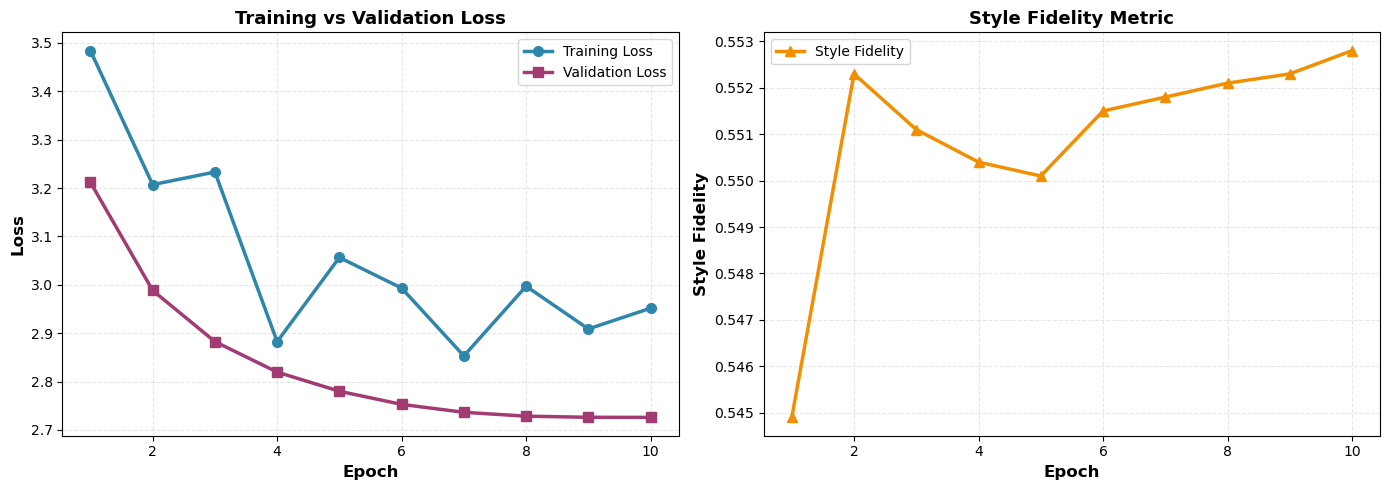

In [28]:
data = {
    'Epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Training Loss': [3.484000, 3.207100, 3.233100, 2.882600, 3.056500, 2.993200, 2.853000, 2.997100, 2.908800, 2.951700],
    'Validation Loss': [3.211928, 2.988371, 2.882592, 2.819603, 2.779973, 2.752839, 2.736468, 2.728484, 2.726157, 2.725961],
    'Style Fidelity': [0.544900, 0.552300, 0.551100, 0.550400, 0.550100, 0.551500, 0.551800, 0.552100, 0.552300, 0.552800],
}

df = pd.DataFrame(data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training vs Validation Loss
ax1.plot(df['Epoch'], df['Training Loss'], marker='o', linewidth=2.5, markersize=7,
         label='Training Loss', color='#2E86AB')
ax1.plot(df['Epoch'], df['Validation Loss'], marker='s', linewidth=2.5, markersize=7,
         label='Validation Loss', color='#A23B72')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=10, loc='best')

# Plot 2: Style Fidelity
ax2.plot(df['Epoch'], df['Style Fidelity'], marker='^', linewidth=2.5, markersize=7,
         label='Style Fidelity', color='#F18F01')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Style Fidelity', fontsize=12, fontweight='bold')
ax2.set_title('Style Fidelity Metric', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()

## T5-Small Test Set Evaluation

Evaluate final model performance on the held-out test set and reload the best checkpoint (Epoch 10) for inference testing.

In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained(T5_OUTPUT_DIR)
tokenizer = AutoTokenizer.from_pretrained(T5_OUTPUT_DIR)
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=ds_tokenized['train'],
    eval_dataset=ds_tokenized['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

First, we run the model on the test split and compute the key metrics we have monitored before. As we can see in the trainer initiliazation above, it will utilise the same `compute_metrics` function, where we will get: loss, style fidelity, semantic quality (BERTScore), and slang fidelity. That gives us a quantitative summary of how well the model generalizes beyond the training and validation sets.

Then, we decode a couple of examples and print the input, the model’s Gen Z prediction, and the reference Gen Z completion side by side. This lets us quickly check whether the outputs both preserve meaning and use slang in a natural way, instead of just trusting the metrics.

Finally, we export to CSV files test inputs, predictions, labels, and the aggregated metrics. This way we can do analysis with way more data in case it is needed. Also, it will come handy later when we compare this T5 model directly against the BART pipeline (will be shown below) without having to rerun the whole evaluation.

In [ ]:
# Decode inputs and labels
inputs = tokenizer.batch_decode(ds_tokenized['test']['input_ids'], skip_special_tokens=True)
labels = tokenizer.batch_decode(ds_tokenized['test']['labels'], skip_special_tokens=True)

# Get predictions
test_output = trainer.predict(ds_tokenized['test'])
pred_ids = np.asarray(test_output.predictions)

# Handle logits vs token IDs
if pred_ids.ndim == 3:
    pred_ids = np.argmax(pred_ids, axis=-1)

# Clean up negative token IDs
pred_ids = np.where(pred_ids < 0, tokenizer.pad_token_id, pred_ids)
predictions = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)

metrics = test_output.metrics

# Display preformance
print(f"Tested model for :       {ds_tokenized['test'].num_rows}")
print(f"Model performance:")
print(f"  - Loss:                {metrics['test_loss']:.4f}")
print(f"  - Style Fidelity:      {metrics['test_style_fidelity']:.4f}")
print(f"  - Semantic Quality:    {metrics['test_bertscore_f1']:.4f}")
print(f"  - Slang Fidelity:      {metrics['test_slang_fidelity']:.4f}")


# Display Sample Predictions 
print("Predictions\n")

num_display = min(2, ds_tokenized['test'].num_rows)
for idx in range(num_display):
    print(f"[Example {idx}]")
    print(f"Input:      {inputs[idx][:120]}...")
    print(f"Prediction: {predictions[idx][:120]}...")
    print(f"Label:      {labels[idx][:120]}...")
    print("-"*100 + "\n")


# Create dataframe with predictions
results = pd.DataFrame({
    'example_id': range(ds_tokenized['test'].num_rows),
    'input': inputs,
    'prediction': predictions,
    'label': labels
})

predictions_file = T5_OUTPUT_DIR + '/test_predictions.csv'
results.to_csv(predictions_file, index=False)
print(f"Saved predictions: {predictions_file}")

# Save metrics
metrics_file = T5_OUTPUT_DIR + '/test_metrics.csv'
pd.DataFrame([metrics]).to_csv(metrics_file, index=False)
print(f"Saved metrics: {metrics_file}\n")


Tested model for :       3000
Model performance:
  - Loss:                2.7042
  - Style Fidelity:      0.5543
  - Semantic Quality:    0.5441
  - Slang Fidelity:      0.6459
Predictions

[Example 0]
Input:      summarize with Gen Z slang: SUBREDDIT: r/relationships TITLE: Me [22/F] with my Mom [56/F]. We argue a lot, want to chan...
Prediction: I’m lowkey stuck in a situationship with my mom, but I can’t even control her feelings. I need a way to be a better girl...
Label:      I keep clashing with Mom and it's lowkey hurting her feels. I'm tired of being a MOMBOY and getting the PSOS vibes, feel...
----------------------------------------------------------------------------------------------------

[Example 1]
Input:      summarize with Gen Z slang: SUBREDDIT: r/AskReddit TITLE: I haven't talked to my dad in a long time (a couple years). I'...
Prediction: I’m lowkey stuck in a tough personal time, need his support, but I don’t want him to think I’ll ask for money. How do I ...
Labe

The T5-small model generalizes well on the 3000-example test set with `style_fidelity = 0.5543`, close to the validation peak of `0.5639`, which is a small gap that can be expected given the metric variability. `Test loss (2.7042)` matches validation, confirming no overfitting.
`Semantic Quality (0.5441)` holds up on unseen data, preserving core summary meaning of the prompt. `Slang Fidelity (0.6459)` tells us the model learned realistic slang density matching our ~8% baseline, which is better than the semantic similarity results.

**Example analysis:** in the example 0 above, slang "situationship" is used (perfect Gen Z term for undefined relationships), although it slightly misses the "improve as daughter" nuance. Example 1 correctly deploys word "lowkey" for understated emotions. Both show appropriate slang usage despite minor semantic gaps.

## Pipeline for BART 

Now, we will repeat the fine-tuning but with a different model - BART. We load the pretrained BART-Base model (139.4 M parameters) and its tokenizer, then move to GPU.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BART_MODEL)
model = AutoModelForSeq2SeqLM.from_pretrained(BART_MODEL)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 139,420,416


We tokenize the data to match the BART model and tokenizer.

In [10]:

ds_tokenized = dataset.map(
    preprocess,
    batched=True,
    num_proc=4,
    remove_columns=dataset["train"].column_names,
    fn_kwargs={"prefix": PREFIX, "tokenizer": tokenizer, "max_input_length": MAX_INPUT_LENGTH, "max_target_length": MAX_TARGET_LENGTH}  
)

ds_tokenized

Map (num_proc=4):   0%|          | 0/3000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/3000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 3000
    })
})

### Trainer Setup

As described earlier, we use identical hyperparameters for BART-base as T5-small (except model-specific token IDs)

In [ ]:
generation_config = GenerationConfig(
    max_length=200,
    num_beams=4,
    
    # These three are REQUIRED for encoder-decoder models
    # decoder_start_token_id=model.config.decoder_start_token_id,
    # pad_token_id=tokenizer.pad_token_id,              # Padding token
    # eos_token_id=tokenizer.eos_token_id,              # End-of-sequence token
    
    # Your anti-repetition settings
    repetition_penalty=1.5,
    no_repeat_ngram_size=3,
)

training_args = Seq2SeqTrainingArguments(
    # Config
    output_dir=BART_OUTPUT_DIR,
    logging_dir=f"{BART_OUTPUT_DIR}/logs",
    report_to="none",                           # Real-time training monitoring
    logging_steps=25,                           # Log metrics every 25 steps
    seed=42,                                    # Reproducibility
    generation_config=generation_config,

    # TRAINING HYPERPARAMETERS
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,                # Initial learning rate for optimizer
    lr_scheduler_type="cosine",                 # Cosine warmup decay schedule
    warmup_ratio=0.06,                          # 6% of total steps for warmup
    weight_decay=0.001,                         # L2 regularization (prevent overfitting)
    max_grad_norm=0.3,                          # Gradient clipping (prevent exploding gradients)

    # Batch Size and Gradient Accumulation (Memory-Critical for Kaggle) Kaggle P100 = 16GB VRAM. 
    per_device_train_batch_size=1,              # Process 1 sample at a time (GPU memory constraint)
    gradient_accumulation_steps=4,              # Accumulate gradients over 4 steps → effective batch = 1×4 = 4
    per_device_eval_batch_size=1,               # Validation batch size (also 1 for memory safety)
    eval_accumulation_steps=1,                  # Accumulate validation predictions (reduces VRAM during eval)

    # MEMORY OPTIMIZATION
    gradient_checkpointing=True,                # Trade compute for memory: recompute gradients instead of storing
    torch_empty_cache_steps=1,                  # Clear GPU cache after every step (prevents fragmentation)
    fp16=True,                                  # Use mixed precision training (float16 + float32)
    fp16_full_eval=True,                        # Evaluate in fp16 to save eval memory
    bf16=False,                                 # Don't use bfloat16 (not needed with fp16)

    # OPTIMIZER CONFIGURATION
    optim="adamw_8bit",

    # CHECKPOINTING & MODEL SELECTION
    save_steps=500,                             # Save checkpoint every 500 training steps
    save_total_limit=NUM_EPOCHS,                # Keep only NUM_EPOCHS most recent checkpoints (saves storage)
    eval_strategy="epoch",                      # Evaluate after each epoch (at train/test split)

    # SEQ2SEQ GENERATION CONFIGURATION (T5-Specific)
    predict_with_generate=True,                 # Use beam search/sampling to generate text (required for Seq2SeqTrainer)
    generation_max_length=142,                  # Match your MAX_TARGET_LENGTH (prevent long/incomplete outputs)
    generation_num_beams=2,                     # Beam search width: 1=greedy (fast), 4+=higher quality (slower) # Set to 4 for better quality if GPU memory allows

    # DATA LOADING OPTIMIZATION
    dataloader_pin_memory=True,                 # Pin GPU memory for faster data transfer (Kaggle-friendly)
    # dataloader_num_workers=0,                 # IMPLICIT: Kaggle doesn't support multiprocessing (leave default)
    remove_unused_columns=True,                # Remove since we don't use the custom metrics for BertScore # (OLD) Keep all dataset columns (in case custom metrics need them)
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,
    return_tensors="pt"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=ds_tokenized['train'],
    eval_dataset=ds_tokenized['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

# Training
We run the fine-tuning similarly as before and save the model and training history.

In [16]:
history = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


Epoch,Training Loss,Validation Loss,Style Fidelity,Bertscore F1,Slang Fidelity
1,2.594600,2.367022,0.548700,0.545100,0.581600
2,2.342000,2.246686,0.557500,0.551500,0.611400
3,2.208500,2.202530,0.562400,0.554800,0.630900
4,2.060200,2.191041,0.563000,0.555600,0.629600
5,1.856300,2.185117,0.561300,0.555800,0.610800
6,1.831700,2.192509,0.563200,0.558400,0.606600
7,1.731300,2.202947,0.564000,0.557200,0.624500
8,1.681600,2.210666,0.563800,0.557400,0.621200
9,1.602300,2.224059,0.563800,0.558200,0.615000
10,1.698400,2.226387,0.563900,0.557700,0.619200


c:\Users\Bjarke\anaconda3\envs\nlp2\lib\site-packages\transformers\modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


In [ ]:
# Save final model & tokenizer & history
model.save_pretrained(BART_OUTPUT_DIR)
tokenizer.save_pretrained(BART_OUTPUT_DIR)

print(f"Training complete! Model saved to {BART_OUTPUT_DIR}")
with open(BART_OUTPUT_DIR + "/train_history.json", "w") as f:
    json.dump(history, f, indent=4)
    
print(f"Training complete! Model saved to {BART_OUTPUT_DIR}")
with open(BART_OUTPUT_DIR + "/log_history.json", "w") as f:
    json.dump(trainer.state.log_history , f, indent=2)

Training complete! Model saved to ./bart-base/output
Training complete! Model saved to ./bart-base/output


Here's how the T5-small model learned over 10 epochs. We tracked both: standard losses, and our custom style_fidelity metric (90% BERTScore semantics + 10% slang density). Again, the metric data comes from the printed table in the trainer's output.

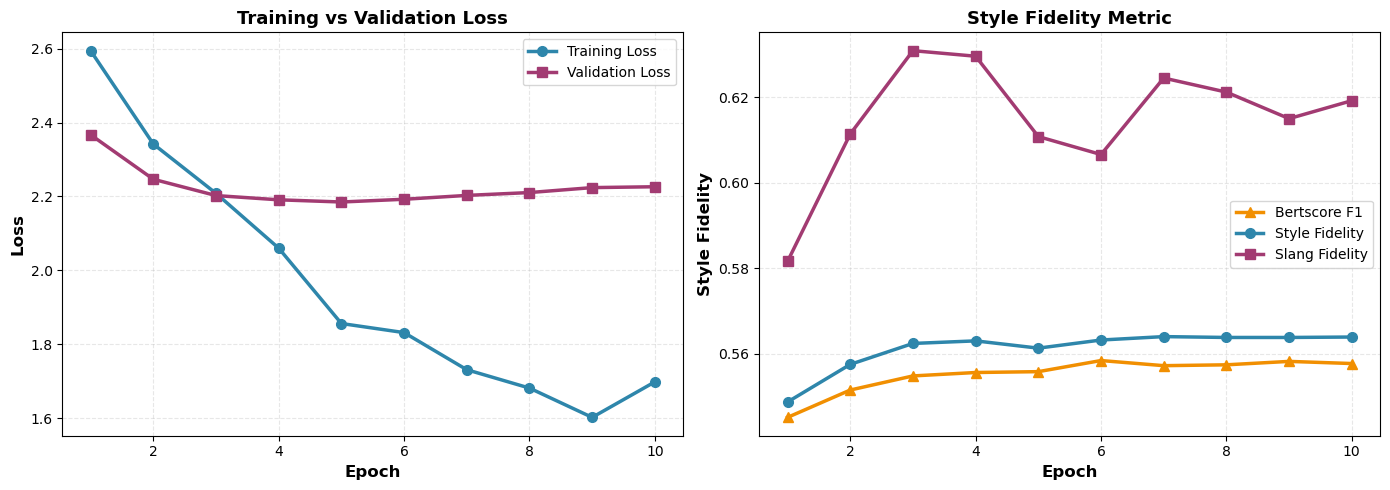

In [40]:
data = {
    'Epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Training Loss': [2.594600, 2.342000, 2.208500, 2.060200, 1.856300, 1.831700, 1.731300, 1.681600, 1.602300, 1.698400],
    'Validation Loss': [2.367022, 2.246686, 2.202530, 2.191041, 2.185117, 2.192509, 2.202947, 2.210666, 2.224059, 2.226387],
    'Style Fidelity': [0.548700, 0.557500, 0.562400, 0.563000, 0.561300, 0.563200, 0.564000, 0.563800, 0.563800, 0.563900],
    'Bertscore F1': [0.545100, 0.551500, 0.554800, 0.555600, 0.555800, 0.558400, 0.557200, 0.557400, 0.558200, 0.557700],
    'Slang Fidelity': [0.581600, 0.611400, 0.630900, 0.629600, 0.610800, 0.606600, 0.624500, 0.621200, 0.615000, 0.619200],
}

df = pd.DataFrame(data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training vs Validation Loss
ax1.plot(df['Epoch'], df['Training Loss'], marker='o', linewidth=2.5, markersize=7,
         label='Training Loss', color='#2E86AB')
ax1.plot(df['Epoch'], df['Validation Loss'], marker='s', linewidth=2.5, markersize=7,
         label='Validation Loss', color='#A23B72')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=10, loc='best')

# Plot 2: Style Fidelity
ax2.plot(df['Epoch'], df['Bertscore F1'], marker='^', linewidth=2.5, markersize=7,
         label='Bertscore F1', color='#F18F01')
ax2.plot(df['Epoch'], df['Style Fidelity'], marker='o', linewidth=2.5, markersize=7,
         label='Style Fidelity', color='#2E86AB')
ax2.plot(df['Epoch'], df['Slang Fidelity'], marker='s', linewidth=2.5, markersize=7,
         label='Slang Fidelity', color='#A23B72')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Style Fidelity', fontsize=12, fontweight='bold')
ax2.set_title('Style Fidelity Metric', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()


Looking at the training curves, Epoch 7 had the peak of `style_fidelity = 0.5640`, with the best balance of validation loss and our custom metric. There is no significant change from there up to epoch 10, which has `style_fidelity = 0.5639`. However, we are saving the results of Epoch 10 as the final checkpoint, since we already trained that far and the difference is tiny (0.0001). Training loss kept dropping a bit and all sub-metrics stayed stable, so there is no overfitting.

## BART Test Set Evaluation
We evaluate the final model performance on the held-out test set and load the best checkpoint (Epoch 10) for inference testing.

In [ ]:
# Load the model and tokenizer from the output directory
model = AutoModelForSeq2SeqLM.from_pretrained(BART_OUTPUT_DIR)
tokenizer = AutoTokenizer.from_pretrained(BART_OUTPUT_DIR)
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=ds_tokenized['train'],
    eval_dataset=ds_tokenized['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

We are again predicting the same way as before.

In [ ]:
# Decode inputs and labels
inputs = tokenizer.batch_decode(ds_tokenized['test']['input_ids'], skip_special_tokens=True)
labels = tokenizer.batch_decode(ds_tokenized['test']['labels'], skip_special_tokens=True)

# Get predictions
test_output = trainer.predict(ds_tokenized['test'])
pred_ids = np.asarray(test_output.predictions)

# Handle logits vs token IDs
if pred_ids.ndim == 3:
    pred_ids = np.argmax(pred_ids, axis=-1)

# Clean up negative token IDs
pred_ids = np.where(pred_ids < 0, tokenizer.pad_token_id, pred_ids)
predictions = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)

metrics = test_output.metrics

# Display preformance
print(f"Tested model for :       {ds_tokenized['test'].num_rows}")
print(f"Model performance:")
print(f"  - Loss:                {metrics['test_loss']:.4f}")
print(f"  - Style Fidelity:      {metrics['test_style_fidelity']:.4f}")
print(f"  - Semantic Quality:    {metrics['test_bertscore_f1']:.4f}")
print(f"  - Slang Fidelity:      {metrics['test_slang_fidelity']:.4f}")


# Display Sample Predictions 

print("Predictions\n")

num_display = min(2, ds_tokenized['test'].num_rows)
for idx in range(num_display):
    print(f"[Example {idx}]")
    print(f"Input:      {inputs[idx][:120]}...")
    print(f"Prediction: {predictions[idx][:120]}...")
    print(f"Label:      {labels[idx][:120]}...")
    print("-"*100 + "\n")


# Create dataframe with predictions
results = pd.DataFrame({
    'example_id': range(ds_tokenized['test'].num_rows),
    'input': inputs,
    'prediction': predictions,
    'label': labels
})

predictions_file = BART_OUTPUT_DIR + '/test_predictions.csv'
results.to_csv(predictions_file, index=False)
print(f"Saved predictions: {predictions_file}")

# Save metrics
metrics_file = BART_OUTPUT_DIR + '/test_metrics.csv'
pd.DataFrame([metrics]).to_csv(metrics_file, index=False)
print(f"Saved metrics: {metrics_file}\n")


Tested model for :       3000
Model performance:
  - Loss:                2.2100
  - Style Fidelity:      0.5637
  - Semantic Quality:    0.5587
  - Slang Fidelity:      0.6087
Predictions

[Example 0]
Input:      summarize with Gen Z slang: SUBREDDIT: r/relationships TITLE: Me [22/F] with my Mom [56/F]. We argue a lot, want to chan...
Prediction: Me and my mom argue a lot, I’m tryna tone it down and be a better daughter. Any tips? PIR, MOS....
Label:      I keep clashing with Mom and it's low‑key hurting her feels. I'm tired of being a MOMBOY and getting the PSOS vibes, fee...
----------------------------------------------------------------------------------------------------

[Example 1]
Input:      summarize with Gen Z slang: SUBREDDIT: r/AskReddit TITLE: I haven't talked to my dad in a long time (a couple years). I'...
Prediction: I’m lowkey dealing with some personal stuff and need my dad’s help, but I don’t wanna look like I’ve asked for cash. Any...
Label:      Yo, I’ve been gho

## Comparison of BART's Results with T5
The comparison between the two models focuses on two aspects: semantic similarity (BERT F1) and slang density. We include the inference results of both fine-tuned models, as-well-as our baseline from the enhanced TL;DR corpus, which was calculated between the original hand-written completions and the synthetically generated Gen Z ones.

#### Slang Density Matching
The slang density statistics show that both BART and T5 closely match the baseline mean (0.0814) and median (0.0769) slang density, with BART almost perfectly aligned and T5 slightly below the target level. Stylistically, this means both models inject slang at roughly the same frequency as our synthetically generated Gen Z completions. The similar standard deviations indicate that neither model collapses into “all slang” or “no slang” modes; instead, they maintain a stable amount of slang per sentence across the dataset, which keeps the summaries easily readable without being too overwhelmingly stylized.

In [16]:

bart_results = pd.read_csv(BART_OUTPUT_DIR + '/test_metrics.csv')
t5_results = pd.read_csv(T5_OUTPUT_DIR + '/test_metrics.csv')

df_default = dataset.to_pandas()

t5_prediction = pd.read_csv(T5_OUTPUT_DIR + '/test_predictions.csv')
bart_prediction = pd.read_csv(BART_OUTPUT_DIR + '/test_predictions.csv')

t5_densities = [slang_score(completion, slang_set) 
             for completion in t5_prediction["prediction"]]

t5_density = pd.Series({
    'min': np.min(t5_densities),
    'max': np.max(t5_densities),
    'mean': np.mean(t5_densities),
    'median': np.median(t5_densities),
    'std': np.std(t5_densities)
})

bart_prediction_densities = [slang_score(completion, slang_set) 
             for completion in bart_prediction["prediction"]]

bart_density = pd.Series({
    'min': np.min(bart_prediction_densities),
    'max': np.max(bart_prediction_densities),
    'mean': np.mean(bart_prediction_densities),
    'median': np.median(bart_prediction_densities),
    'std': np.std(bart_prediction_densities)
})

print("SLANG DENSITY COMPARISON (words per sentence)")
print("=" * 70)

comparison_df = pd.DataFrame({
    'Baseline': [f"{pd_density['min']:.4f}", f"{pd_density['max']:.4f}", 
                 f"{pd_density['mean']:.4f}", f"{pd_density['median']:.4f}", 
                 f"{pd_density['std']:.4f}"],
    'BART': [f"{bart_density['min']:.4f}", f"{bart_density['max']:.4f}", 
             f"{bart_density['mean']:.4f}", f"{bart_density['median']:.4f}", 
             f"{bart_density['std']:.4f}"],
    'T5': [f"{t5_density['min']:.4f}", f"{t5_density['max']:.4f}", 
           f"{t5_density['mean']:.4f}", f"{t5_density['median']:.4f}", 
           f"{t5_density['std']:.4f}"]
}, index=['Min', 'Max', 'Mean', 'Median', 'Std Dev'])

display(comparison_df)

SLANG DENSITY COMPARISON (words per sentence)


,Baseline,BART,T5
Min,0.0000,0.0000,0.0000
Max,1.0000,0.2941,0.2941
Mean,0.0814,0.0805,0.0726
Median,0.0769,0.0769,0.0690
Std Dev,0.0492,0.0490,0.0432


#### Semantic Similarity (BERT F1)

The BERT F1 bar chart shows that the default corpus baseline (synthetically generated Gen Z completions vs completions) has the highest semantic similarity at 0.6333, while BART (0.5587) slightly outperforms T5 (0.5441). This means both fine-tuned models lose some semantic alignment compared to the baseline references, but BART preserves meaning a bit better than T5, which aligns with its larger capacity and stronger encoder–decoder architecture.

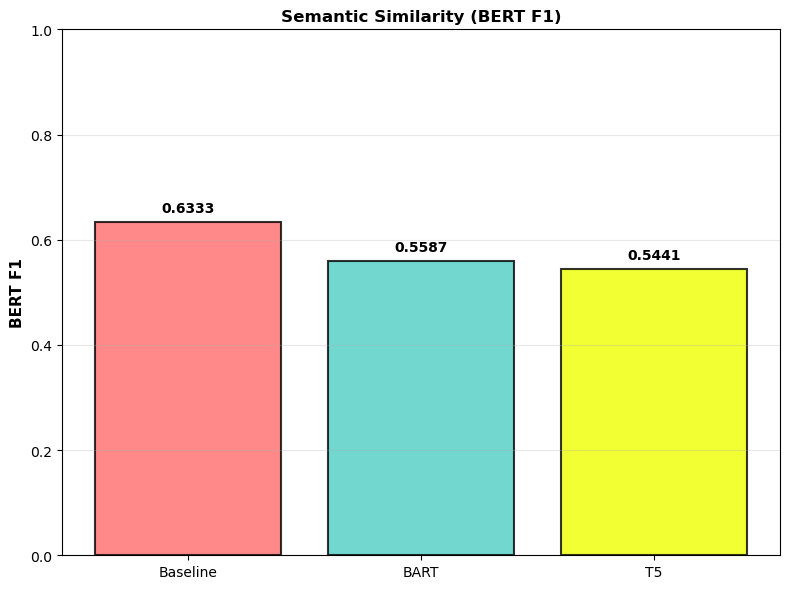

In [32]:
fig, axes = plt.subplots(figsize=(8, 6))

models = ['Baseline', 'BART', 'T5']
bert_scores = [
    df_default['bert_f1'].mean(),
    bart_results['test_bertscore_f1'].values[0],
    t5_results['test_bertscore_f1'].values[0]
]
axes.bar(models, bert_scores, color=['#FF6B6B', '#4ECDC4', "#EEFF00"], alpha=0.8, edgecolor='black', linewidth=1.5)
axes.set_ylabel('BERT F1', fontsize=11, fontweight='bold')
axes.set_title('Semantic Similarity (BERT F1)', fontsize=12, fontweight='bold')
axes.set_ylim([0, 1])
axes.grid(axis='y', alpha=0.3)
for i, v in enumerate(bert_scores):
    axes.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [31]:
comparison = pd.DataFrame({
    'BART': [bart_results.get('test_style_fidelity', 'N/A').item(), bart_results.get('test_bertscore_f1', 'N/A').item(), 
             bart_results.get('test_slang_fidelity', 'N/A').item()],
    'T5': [t5_results.get('test_style_fidelity', 'N/A').item(), 
           t5_results.get('test_bertscore_f1', 'N/A').item(),
           t5_results.get('test_slang_fidelity', 'N/A').item()],
}, index=['Style Fidelity', 'BERTScore F1', 'Slang Fidelity']).round(4)
display(comparison)

,BART,T5
Style Fidelity,0.5637,0.5543
BERTScore F1,0.5587,0.5441
Slang Fidelity,0.6087,0.6459


##### Observed discrepancy

At first glance, there appears to be a mismatch between the slang density statistics and the slang_fidelity metric:

- The slang density table shows that **BART’s mean density (0.0805)** is closer to the **baseline mean (0.0814)** than **T5’s mean (0.0726)**, and the medians follow the same pattern.  
- However, the evaluation metrics report **higher slang_fidelity for T5 (0.6459)** than for **BART (0.6087)**.

##### Interpretation

This is not a contradiction but a consequence of how we have originally defined **slang_fidelity**. The density table summarizes the **global distribution** (mean, median, std) of slang usage across the test set. In contrast, slang_fidelity is computed **per example** and then averaged, remember:

$\text{slang\_fidelity}_i = \max\left(0.0, 1.0 - \frac{|\text{pred\_density}_i - \text{baseline\_mean}|}{2 \times \text{baseline\_std}}\right)$ .

This formulation rewards predictions whose **individual slang density** lies within a ±2σ band around the baseline mean and penalizes examples that deviate strongly in either direction.

Under this metric, it is possible for:

- **BART** to have a global mean very close to the baseline, while still producing more sentences that are either slightly too low or relatively high in slang density.
- **T5** to have a global mean that is slightly further from the baseline, but with **more individual sentences** staying inside the tolerated range around the mean.

As a result, T5 can obtain a **higher average slang_fidelity** score, even though its overall mean density is somewhat lower than BART’s. This suggests that T5’s slang usage is **more uniformly calibrated at the sentence level**, whereas BART’s slang usage is **globally well-centered** but potentially more variable across individual output examples.

### Summary of this Evaluation
BART offers the best overall trade-off among both fine-tuned models: it achieves higher semantic similarity than T5 while remaining closely aligned with the baseline slang density. T5 shows slightly weaker semantic scores and somewhat lower slang density, but still stays near the target distribution and uses slang in a controlled, non-degenerate way. Altogether, these results indicate that BART is the preferable choice when the goal is to maximise meaning preservation while maintaining realistic Gen Z slang patterns, whereas T5 remains a reasonable lighter-weight alternative that sacrifices a small amount of both semantics and slang fidelity.

## Evaluation of the results using an LLM

We have chosen to conduct a second evaluation.
Directly comparing thousands of generated summaries is difficult, so we additionally evaluate model quality using an external LLM as a judge. To do this, we create a JSONL file with all inputs and model outputs and submit it to Amazon Bedrock Batch Inference, which scores every example in a single offline job. This batch setup reduces cost and avoids maintaining a persistent API connection during large-scale evaluation.

**LLM-Based Evaluation Prompt**

This evaluation prompt is designed to score model-generated summaries that must solve two tasks simultaneously: preserve the factual content of the original Reddit post and transform the style into authentic Gen Z slang. The goal is to obtain a standardized, interpretable score that lets us compare T5 and BART beyond automatic metrics like ROUGE or BERTScore.


The prompt asks an LLM to rate each output on three distinct dimensions:

| Category             | What it measures                                                   | Why it matters                                               |
|----------------------|--------------------------------------------------------------------|--------------------------------------------------------------|
| Meaning Preservation | Factual accuracy and whether the core message is still intact     | Style is useless if key facts are lost or distorted          |
| Slang Quality        | Natural, context-appropriate Gen Z slang that avoids "cringe"     | Overused or random slang makes the text sound inauthentic    |
| Reddit Naturalness   | Whether the summary reads like a real Reddit TL;DR, not an AI     | Authenticity requires matching community tone, not just slang|

This setup separates *what* is being said (meaning) from *how* it is said (slang + Reddit voice), which traditional metrics cannot do reliably.

### Why an LLM judge is needed

Standard automatic metrics are insufficient for this task:

- **ROUGE** penalizes paraphrases into slang even when they are correct.
- **BERTScore** captures semantic similarity but does not measure new slang words or over-the-top ones, because it doesn't have accurate tokens for them.
- No existing metric captures "Reddit TL;DR authenticity" as a style target.

Using an LLM as a judge allows us to explicitly score these human-centric aspects on a 1–5 scale (5 being the best) per dimension.


### Example rating

Original:  
> "I'm arguing with my mom and feel defensive around her."

Model output:  
> "bruh im lowkey beefing with my mum fr fr no cap"

Illustrative scores:

- **Meaning**: 4/5 – The core conflict with the mother is preserved, but "beefing" is slightly stronger than "arguing".
- **Slang**: 3/5 – Uses plausible slang, but "fr fr no cap" is overused and feels a bit forced.
- **Reddit naturalness**: 4/5 – Reads like a Reddit post, though the slang density is slightly higher than typical.

Overall: 11/15 – Good attempt but could use more balance.

### Rating scale

| Score | Interpretation                        |
|-------|---------------------------------------|
| 5     | Excellent: natural Gen Z, fully correct meaning, Reddit-like |
| 4     | Strong: minor issues in style or small factual softening     |
| 3     | Acceptable: understandable, some awkwardness or noise        |
| 2     | Weak: clear problems with meaning or obviously cringe slang  |
| 1     | Failed: major meaning loss or nonsensical slang              |


### Preparing Evaluation Batches for the LLM Judge
In this step, the test-set outputs are converted into a JSONL format that the LLM judge (via Amazon Bedrock Batch Inference) can process. Each JSONL record contains the original Reddit prompt, the default Gen Z completion, and the corresponding T5 and BART summaries, allowing the agent to score all systems under the same evaluation prompt in a single offline batch.

In [8]:
create_evaluation_baseline_batch(T5_OUTPUT_DIR + "/test_predictions.csv")

Created 3000 batch requests

Creating batch input file: evaluation_batch_1.jsonl


In [ ]:
create_evaluation_batch(T5_PREDICTIONS_FILE=T5_OUTPUT_DIR + "/test_predictions.csv", BART_PREDICTIONS_FILE=BART_OUTPUT_DIR + "/test_predictions.csv")

Created 6000 batch requests

Creating batch input file: evaluation_batch.jsonl


### Parse the data from the evaluation files
We load the results from the LLM judge.

In [19]:
df_baseline = parse_evaluation_results("Data/evaluation_batch_1.jsonl")

Loading Data/evaluation_batch_1.jsonl...
Parsed 3000 rows


In [ ]:
df_results = parse_evaluation_results("Data/evaluation_batch.jsonl")
# Replace all model with the baseline

Loading Data/evaluation_batch.jsonl...
Parsed 6000 rows


C:\Users\Bjarke\AppData\Local\Temp\ipykernel_10640\2279549815.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_results.baseline = df_baseline


In [28]:
display(df_baseline)
df_baseline.to_csv("Data/evaluation_baseline_results.csv", index=False)

,model,record_id,meaning,slang,reddit,overall,notes
0,baseline,95,1,2,2,5,The summary drops most of the story (drunk mov...
1,baseline,92,1,2,2,5,The summary drops virtually all the specific q...
2,baseline,83,1,2,2,5,The summary misses virtually all key details (...
3,baseline,15,2,2,2,6,"The summary mangles key facts (pregnant mom, u..."
4,baseline,81,4,4,4,12,"Good slang and captures core question, but dro..."
...,...,...,...,...,...,...,...
2995,baseline,2996,4,2,3,9,Captures the main request about wanting cuddle...
2996,baseline,3000,2,2,2,6,"Meaning missing key details, slang forced, not..."
2997,baseline,2981,3,2,2,7,Meaning roughly captured but missing key detai...
2998,baseline,2997,4,2,3,9,Captures the core situation (ex is best friend...


In [29]:
display(df_results)
df_results.to_csv("Data/final_evaluation_results.csv", index=False)

,model,record_id,meaning,slang,reddit,overall,notes
0,t5,23,1,2,1,4,The summary completely misrepresents the origi...
1,t5,63,2,3,3,8,The summary captures the nervous vibe and the ...
2,t5,45,1,2,2,5,The summary strips away all key details (broth...
3,t5,36,1,2,2,5,The summary completely misrepresents the post ...
4,t5,87,1,2,2,5,The summary drops the core request for realist...
...,...,...,...,...,...,...,...
5995,bart,5985,2,2,2,6,Misses key facts (friend actually hooked up wi...
5996,bart,5931,3,2,3,8,brief explanation.
5997,bart,5670,1,3,3,7,"Explain lack of meaning, limited slang, decent..."
5998,bart,5980,2,2,2,6,"[brief explanation]"""


### Compare the results

In [ ]:
t5_results = df_results[df_results['model'] == 't5']
bart_results = df_results[df_results['model'] == 'bart']


comparison_summary = pd.DataFrame({
    'Meaning': [df_baseline['meaning'].mean(), t5_results['meaning'].mean(), bart_results['meaning'].mean()],
    'Slang': [df_baseline['slang'].mean(), t5_results['slang'].mean(), bart_results['slang'].mean()],
    'Reddit': [df_baseline['reddit'].mean(), t5_results['reddit'].mean(), bart_results['reddit'].mean()],
    'Overall': [df_baseline['overall'].mean(), t5_results['overall'].mean(), bart_results['overall'].mean()]
}, index=['Baseline', 'T5', 'BART'])
display(comparison_summary)


,Meaning,Slang,Reddit,Overall
Baseline,2.324667,2.498667,2.578333,7.401667
T5,1.722667,2.427333,2.414667,6.564667
BART,2.203000,2.709333,2.752000,7.664333


The table above shows how an external LLM judge rated the summaries from the baseline, T5, and BART systems on a 1–5 scale per dimension, with higher scores indicating better quality. The `Overall` column is a sum of the three dimensions, meaning the best total value is 15.

## Interpretation of the Results and Discussion

The baseline Gen Z completions achieve only moderate scores across Meaning, Slang, and Reddit dimensions. This suggests that the synthetic reference data itself is imperfect and may limit how good the supervised models can be fine-tuned, since they are trained to imitate these labels. A more robust approach would be to regenerate the synthetic Gen Z completions with a stronger LLM and filter them online using the same LLM-judging scheme, discarding any completions whose scores fall below a chosen threshold; this would produce a higher‑quality “gold” baseline for future training.

T5 obtains the lowest scores in all three categories. The reduced Meaning score indicates more frequent semantic drift or omission of important details compared to both the baseline and BART. Its slightly lower Slang and Reddit scores further suggest that its style is judged as less natural and less Reddit‑like, even though it still uses Gen Z elements.

BART improves over T5 on all three dimensions and slightly surpasses the baseline in Slang and Reddit scores. The higher Slang and Reddit ratings indicate that BART’s outputs are perceived as more fluent in Gen Z slang and more consistent with Reddit TL;DR style, while maintaining competitive meaning preservation relative to the baseline.

### Conclusion

Because higher scores are better, BART is the preferred model: it achieves the highest overall score and consistently outperforms T5 on Meaning, Slang, and Reddit criteria. The baseline remains competitive on Meaning but is clearly weaker stylistically. This indicates that supervised fine‑tuning with BART yields summaries that are both more semantically reliable than T5 and more stylistically aligned with Gen Z Reddit discourse than the original synthetic baseline.